# Livrable 1 — Modélisation formelle du problème
## Optimisation de tournées avec contraintes

**Structure :** CesiCDP  
**Équipe 1 :** ROBIN Thomas, LEDOUX Bastien, LIN Alexandre, FOURFOOZ Luca

---

## Table des matières

1. [Contexte](#1)
2. [Définition informelle du problème](#2)
3. [Représentation formelle des données](#3)
4. [Formulation du problème d'optimisation](#4)
5. [Contraintes supplémentaires retenues](#5)
   - 5.1 [Fenêtres temporelles (Time Windows)](#5-1)
   - 5.2 [Coût et restrictions sur certaines arêtes](#5-2)
6. [Références bibliographiques](#6)
7. [Réalisation](#7)
8. [Plan d'expérience](#8)

---
## 1. Contexte<a id="1"></a>

### 1.1 Enjeux environnementaux et réglementaires

Pour atteindre l'objectif français de diviser par quatre les émissions de gaz à effet de serre d'ici 2050, le secteur des transports (30% des émissions) est une priorité. 

Dans le cadre d'un appel à projets de l'**ADEME**, notre structure **CesiCDP** a pour mission de concevoir un algorithme d'optimisation de tournées (livraison, collecte). L'enjeu : minimiser l'impact environnemental des flottes de véhicules tout en respectant des contraintes métiers strictes.

### 1.2. Le problème algorithmique en 2 minutes

Derrière cet enjeu se cache le célèbre "Problème du Voyageur de Commerce" avec contraintes (VRP). 
**Le but :** Trouver le meilleur ordre pour visiter une liste d'adresses en perdant le moins de temps et de carburant possible.

La difficulté repose sur **l'explosion combinatoire** : avec seulement 10 adresses, il existe déjà **3 628 800 parcours possibles** (10!). À cela s'ajoutent les réalités du terrain :

* **Fenêtres temporelles :** Le client n'est là qu'entre 14h et 16h.
* **Perturbations :** Une rue est bloquée pour travaux.
* **Capacités :** Le camion ne peut contenir qu'un nombre limité de colis.

### 1.3. Illustration : Le défi de "Livraison-sur-Algorithme"

Imaginons un livreur partant de son entrepôt (**E₀**) à 8h00 pour 6 points (A à F) :

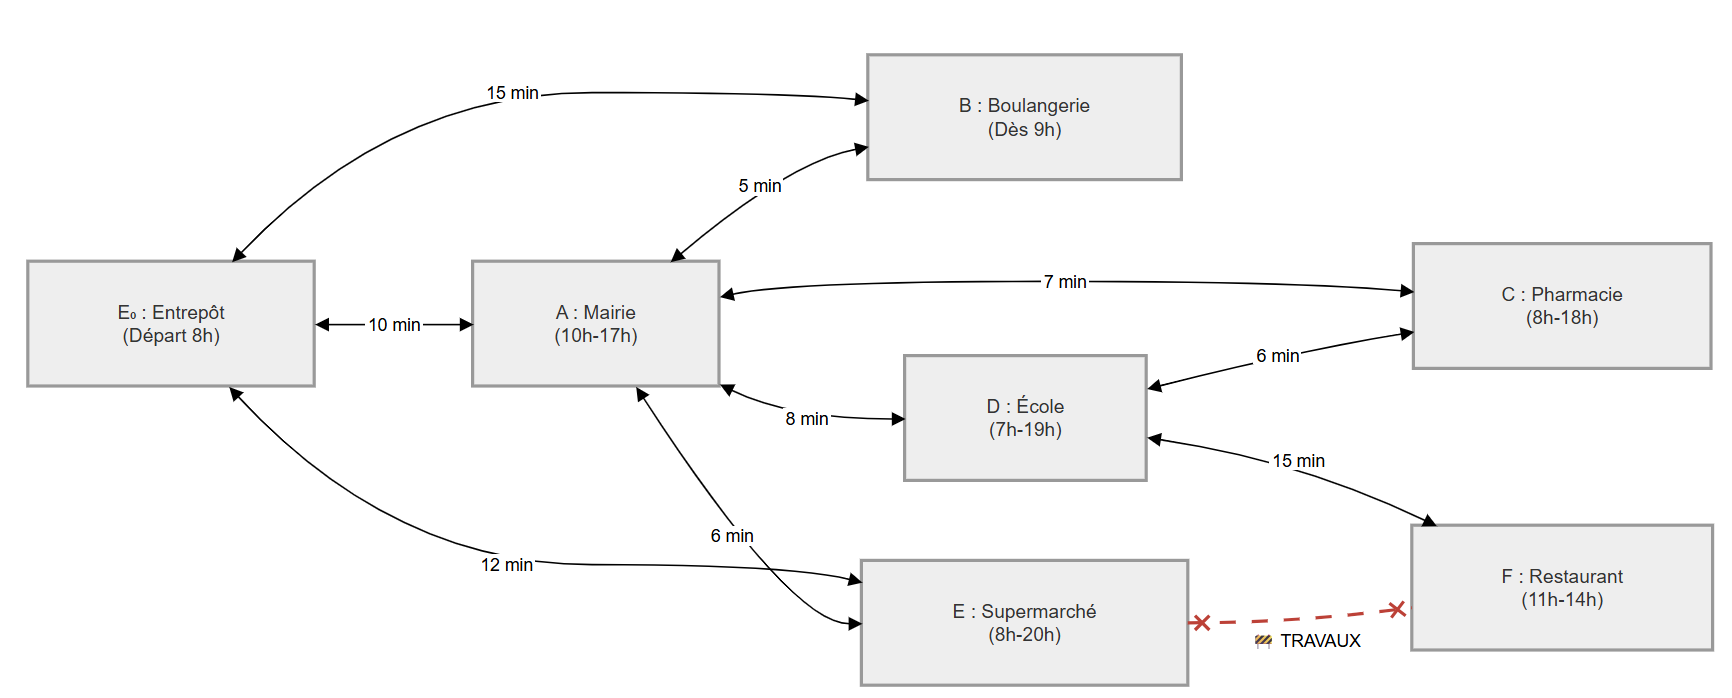

**Le casse-tête :**
* **Mauvais parcours :** `E₀ → E → F`  *Impossible, la route entre E et F est en travaux.*
* **Mauvais parcours :** `E₀ → B` (arrivée à 8h15)  *La boulangerie n'ouvre qu'à 9h !*

### 1.4 Objectif algorithmique

Ce document, qui constitue la première étape de notre réponse à l'ADEME, a pour but de poser les fondations théoriques et pratiques de notre solution. 

Le problème central consiste à **calculer sur un réseau routier une tournée optimale** reliant un sous-ensemble de villes, en revenant au point de départ, de manière à **minimiser la durée totale du trajet**, tout en respectant les contraintes opérationnelles réelles.

Dans ce projet, nous développons des **algorithmes** capables de trouver automatiquement le meilleur parcours, de gérer des centaines de points de livraison et de s'adapter à toutes les contraintes du terrain (horaires, routes bloquées, coûts). À travers ce Notebook, nous allons :

1. **Modéliser mathématiquement** ce problème logistique (Graphes, sommets, arêtes, fonctions de coût).
2. **Intégrer les contraintes complexes** (notamment les fenêtres de temps et les capacités multiples) pour coller à la réalité du terrain.
3. **Analyser la complexité théorique** du problème pour justifier les choix algorithmiques futurs.

**L'objectif final est clair :** Concevoir une intelligence logistique capable de trouver le trajet optimal instantanément pour réduire l'empreinte carbone de nos partenaires. 
**Impact réel :** Moins de kilomètres = moins de carburant = moins de CO₂

---
## 2. Définition informelle du problème <a id="2"></a>

### 2.1 Le problème du Voyageur de Commerce (TSP)

Le problème de base sous-jacent est le célèbre **Travelling Salesman Problem (TSP)**, formulé historiquement par Dantzig, Fulkerson et Johnson en 1954 [1]. Dans sa version classique :

> *Étant donné un ensemble de villes et les distances entre chacune d'elles, trouver le chemin le plus court passant par toutes les villes exactement une fois et revenant à la ville de départ.*

### 2.2 Extension à notre contexte opérationnel

Notre problème s'écarte du TSP classique sur plusieurs points essentiels :

1. **Le graphe n'est pas nécessairement complet** : certaines routes n'existent pas ou sont interdites (travaux, zones à accès restreint).
2. **Les arêtes ont des coûts hétérogènes** : certaines routes sont plus coûteuses (péages, voies dégradées, zones de congestion).
3. **Les villes ont des fenêtres temporelles** : un point de livraison n'est accessible que dans un créneau horaire.

Ce problème enrichi est connu dans la littérature sous le nom de **TSP with Time Windows and Edge Restrictions (TSPTW-R)**.

### 2.3 Un problème intrinsèquement difficile : NP-complétude

Avant d'aller plus loin dans la modélisation, il est essentiel de souligner pourquoi ce problème est **fondamentalement difficile à résoudre**. Le TSPTW-R est un problème **NP-complet**, ce que nous démontrons ici par une chaîne de réductions.

#### Rappels

Un problème est **NP-complet** s'il vérifie deux conditions :
- **∈ NP** : une solution candidate peut être *vérifiée* en temps polynomial.
- **NP-difficile** : tout problème de NP s'y réduit polynomialement — autrement dit, le résoudre efficacement permettrait de résoudre efficacement tous les problèmes de NP.

#### Étape 1 : Le TSP est NP-complet

**TSP ∈ NP :** Étant donné une tournée candidate $\pi = (\pi_1, \ldots, \pi_n)$, on vérifie en $O(n)$ que chaque sommet apparaît exactement une fois et que le coût total est $\leq k$. ✓

**TSP est NP-difficile** (réduction depuis le Circuit Hamiltonien) : Le problème HC — *"existe-t-il un cycle passant par chaque sommet exactement une fois dans un graphe non pondéré $G=(V,E)$ ?"* — est NP-complet (Karp, 1972 [6]). On lui associe l'instance TSP suivante :

$$w'(i,j) = \begin{cases} 0 & \text{si } (i,j) \in E \\ 1 & \text{sinon} \end{cases} \qquad k = 0$$

Cette construction est polynomiale ($O(n^2)$). La double implication est immédiate :
- Si $G$ a un circuit hamiltonien, ce circuit a un coût $0$ dans l'instance TSP → réponse **OUI**.
- Si une tournée de coût $\leq 0$ existe dans l'instance TSP, tous ses poids valent $0$, donc toutes ses arêtes sont dans $E$ → circuit hamiltonien dans $G$ → réponse **OUI**.

Donc **HC $\leq_P$ TSP**, et le TSP est NP-complet.

#### Étape 2 : Le TSPTW-R est NP-complet par généralisation

Le TSP est un cas particulier du TSPTW-R : il suffit de poser $a_i=0,\, b_i=+\infty,\, s_i=0$ pour tout sommet (fenêtres infinies) et $c(i,j)=1$ pour toute arête (aucune restriction). Ces transformations sont en $O(n)$. Donc :

$$\text{HC} \leq_P \text{TSP} \leq_P \text{TSPTW-R}$$

Une solution de TSPTW-R se vérifie en $O(n)$ (ordre de visite, fenêtres, restrictions, coût). Donc TSPTW-R $\in$ NP.

$$\boxed{\text{TSPTW-R est NP-complet}}$$

---
## 3. Représentation formelle des données <a id="3"></a>

### 3.1 Structure de graphe

Le réseau routier est modélisé par un **graphe orienté pondéré** :

$$G = (V, E, w, c)$$

où :

| Symbole | Type | Définition |
|---|---|---|
| $V$ | Ensemble fini | Ensemble des $n$ sommets (villes / points de livraison) |
| $E \subseteq V \times V$ | Ensemble d'arêtes | Routes existantes entre les villes |
| $w : E \rightarrow \mathbb{R}^+$ | Fonction de coût | Temps de parcours (ou distance) de chaque arête |
| $c : E \rightarrow \{0, 1, \mathbb{R}^+\}$ | Fonction de restriction | $0$ = arête interdite, $r > 1$ = surcoût multiplicatif |

**Convention :** Le sommet $v_0 \in V$ désigne le **dépôt** (point de départ et d'arrivée de la tournée).

### 3.2 Données associées aux sommets

À chaque sommet $v_i \in V \setminus \{v_0\}$ est associé un vecteur d'attributs :

$$v_i \leftarrow (a_i, b_i, s_i)$$

où :
- $a_i \in \mathbb{R}^+$ : **début de la fenêtre temporelle** 
- $b_i \in \mathbb{R}^+$ : **fin de la fenêtre temporelle**, avec $a_i \leq b_i$
- $s_i \in \mathbb{R}^+$ : **temps de service** au sommet $i$ 

Le dépôt $v_0$ a par convention $a_0 = 0$, $b_0 = +\infty$, $s_0 = 0$.

### 3.3 Données associées aux arêtes

Le **coût effectif** de traversée d'une arête $(i, j) \in E$ est défini par :

$$\tilde{w}(i,j) = 
\begin{cases}
+\infty & \text{si } c(i,j) = 0 \quad \text{(arête interdite)} \\
w(i,j) \times c(i,j) & \text{si } c(i,j) > 0 \quad \text{(coût normal ou majoré)}
\end{cases}$$

Ainsi, les arêtes interdites sont effectivement exclues de toute solution faisable, et les arêtes coûteuses sont pénalisées proportionnellement.

### 3.4 Représentation matricielle

Pour faciliter l'implémentation algorithmique, on représente le graphe par deux matrices $n \times n$ :

- **Matrice de temps de parcours** $W$ : $W[i][j] = w(i,j)$ si $(i,j) \in E$, $+\infty$ sinon
- **Matrice de restrictions** $C$ : $C[i][j] = c(i,j)$ si $(i,j) \in E$, $0$ sinon
- **Matrice de coûts effectifs** $\tilde{W}$ : $\tilde{W}[i][j] = \tilde{w}(i,j)$

---
## 4. Formulation du problème d'optimisation <a id="4"></a>

### 4.1 Variables de décision

On introduit les variables binaires :

$$x_{ij} \in \{0, 1\}, \quad \forall (i,j) \in E$$

avec la sémantique : $x_{ij} = 1$ si et seulement si l'arête $(i, j)$ est **empruntée** dans la tournée.

On définit également les variables de temps de passage :

$$t_i \in \mathbb{R}^+, \quad \forall i \in V$$

représentant le **temps d'arrivée** au sommet $i$.

### 4.2 Fonction objectif

On cherche à **minimiser le coût total de la tournée** :

$$\min \sum_{(i,j) \in E} \tilde{w}(i,j) \cdot x_{ij}$$

### 4.3 Contraintes de base (TSP)

**Chaque sommet est visité exactement une fois :**

$$\sum_{j : (i,j) \in E} x_{ij} = 1, \quad \forall i \in V$$

$$\sum_{i : (i,j) \in E} x_{ij} = 1, \quad \forall j \in V$$

**Élimination des sous-tours (contraintes de Miller-Tucker-Zemlin [2]) :**

On introduit des variables auxiliaires $u_i \in \{1, \ldots, n\}$ :

$$u_i - u_j + n \cdot x_{ij} \leq n - 1, \quad \forall i \neq j \in V \setminus \{v_0\}$$

$$x_{ij} \in \{0, 1\}, \quad u_i \in \mathbb{Z}^+$$

*Note : Ces contraintes MTZ garantissent que la solution forme un unique cycle hamiltonien, sans sous-tours disjoints.*

---
## 5. Contraintes supplémentaires retenues <a id="5"></a>

Conformément aux exigences du projet, l'équipe a retenu **deux contraintes supplémentaires** parmi la liste proposée. Ces contraintes ont été choisies pour leur pertinence applicative (adéquation avec les cas réels de livraison) et leur relative accessibilité d'implémentation.


### 5.1 Contrainte 1, Fenêtres temporelles (Time Windows) <a id="5-1"></a>

Dans la réalité, les destinataires d'une livraison ne sont pas disponibles à toute heure. Un commerce ouvre à 8h et ferme à 18h, un particulier est disponible uniquement entre 14h et 16h. Le livreur doit **arriver dans le créneau autorisé**, sous peine de devoir repartir sans effectuer la livraison.

#### Formalisation

Chaque sommet $v_i \in V \setminus \{v_0\}$ est associé à un intervalle $[a_i, b_i]$. La **variable de temps de passage** $t_i$ doit satisfaire :

$$a_i \leq t_i \leq b_i, \quad \forall i \in V \setminus \{v_0\}$$

#### Cohérence temporelle entre sommets successifs

Si le sommet $j$ est visité juste après le sommet $i$, alors le temps d'arrivée en $j$ doit respecter :

$$t_j \geq (t_i + s_i + \tilde{w}(i,j)) \cdot x_{ij}, \quad \forall (i,j) \in E$$

Pour linéariser cette contrainte, on utilise la forme MTZ avec big-M [3] :

$$t_j \geq t_i + s_i + \tilde{w}(i,j) - M(1 - x_{ij}), \quad \forall (i,j) \in E$$

avec $M$ une constante suffisamment grande (typiquement $M = \sum_{(i,j) \in E} \tilde{w}(i,j)$).

#### Gestion des attentes

Si le livreur arrive avant l'ouverture de la fenêtre ($t_i < a_i$), il **attend** sur place. Le temps effectif de départ de $i$ est donc $\max(t_i, a_i) + s_i$. Cela se modélise en redéfinissant le temps de départ effectif :

$$d_i = \max(t_i, a_i) + s_i$$

#### Type de fenêtres : hard vs soft

| Type | Définition | Notre choix |
|---|---|---|
| **Hard Time Windows** | $t_i > b_i$ rend la solution **infaisable** | ✓ Retenu |
| Soft Time Windows | $t_i > b_i$ est autorisé mais **pénalisé** dans l'objectif | Non retenu |

Nous utilisons des **fenêtres dures** (hard), ce qui est la formulation la plus répandue dans la littérature TSPTW [4].

---

### 5.2 Contrainte 2, Coût et restrictions sur certaines arêtes <a id="5-2"></a>

#### Motivation

Un réseau routier réel n'est pas homogène. Certains axes sont temporairement fermés (travaux, accidents), d'autres sont soumis à des péages ou présentent des difficultés de circulation (zones piétonnes partielles, gabarit limité). Modéliser ces hétérogénéités est essentiel pour obtenir des tournées réalistes.

#### Formalisation

On enrichit le graphe avec la fonction de restriction $c : E \rightarrow \mathbb{R}^+ \cup \{0\}$ définie comme :

$$c(i,j) = \begin{cases}
0 & \text{route interdite (ex : travaux, sens interdit)} \\
1 & \text{route normale} \\
r > 1 & \text{surcoût multiplicatif (ex : péage, voie dégradée)}
\end{cases}$$

Le **coût effectif** de l'arête $(i,j)$ devient :

$$\tilde{w}(i,j) = \begin{cases}
+\infty \\
w(i,j) \times c(i,j)
\end{cases}$$

#### Impact sur la faisabilité

La présence d'arêtes interdites peut rendre le graphe **non-hamiltonien** : il peut exister des instances où aucune tournée complète n'est réalisable. Il faut donc, lors de la génération d'instances, s'assurer de la **connexité** du graphe résiduel (après suppression des arêtes interdites).

**Condition nécessaire de faisabilité :**

$$\forall i \in V, \quad \exists j \in V : (i,j) \in E \text{ et } c(i,j) > 0$$

---
## 6. Références bibliographiques <a id="6"></a>

[1] **Dantzig, G.B., Fulkerson, D.R., Johnson, S.M.** (1954). *Solution of a large-scale traveling-salesman problem*. Journal of the Operations Research Society of America, 2(4), 393-410. [DOI:10.1287/opre.2.4.393](https://doi.org/10.1287/opre.2.4.393)

[2] **Miller, C.E., Tucker, A.W., Zemlin, R.A.** (1960). *Integer programming formulation of traveling salesman problems*. Journal of the ACM, 7(4), 326-329. [DOI:10.1145/321043.321046](https://doi.org/10.1145/321043.321046)

[3] **Desrochers, M., Laporte, G.** (1991). *Improvements and extensions to the Miller-Tucker-Zemlin subtour elimination constraints*. Operations Research Letters, 10(1), 27-36. [DOI:10.1016/0167-6377(91)90083-2](https://doi.org/10.1016/0167-6377(91)90083-2)

[4] **Savelsbergh, M.W.P.** (1985). *Local search in routing problems with time windows*. Annals of Operations Research, 4(1), 285-305. [DOI:10.1007/BF02022044](https://doi.org/10.1007/BF02022044)

[5] **Garey, M.R., Johnson, D.S.** (1979). *Computers and Intractability: A Guide to the Theory of NP-Completeness*. W.H. Freeman and Company. ISBN: 978-0-7167-1045-5.

[6] **Karp, R.M.** (1972). *Reducibility among combinatorial problems*. In R.E. Miller & J.W. Thatcher (Eds.), *Complexity of Computer Computations* (pp. 85-103). Plenum Press. [DOI:10.1007/978-1-4684-2001-2_9](https://doi.org/10.1007/978-1-4684-2001-2_9)

[7] **Solomon, M.M.** (1987). *Algorithms for the vehicle routing and scheduling problems with time window constraints*. Operations Research, 35(2), 254-265. [DOI:10.1287/opre.35.2.254](https://doi.org/10.1287/opre.35.2.254)

---

## 7. Réalisation <a id="7"></a>

### Variables

In [19]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              VARIABLES — MODIFICATION RAPIDE                 ║
# ╚══════════════════════════════════════════════════════════════╝

# --- Génération d'instances ---
NB_VILLES          = 30    # Nombre de villes (incluant le dépôt)
TAILLE_GRILLE      = 100   # Taille de la grille (coordonnées de 0 à TAILLE_GRILLE)
PROBA_PERTURBATION = 0.3   # Probabilité de perturbation (bouchon ou route bloquée)

# --- Algorithme 1 : Hill Climbing ---
HC_MAX_ITER = 50           # Nb max d'itérations sans amélioration avant arrêt

# --- Algorithme 2 : Recherche Tabou ---
TABOU_TAILLE      = 20     # Taille de la liste tabou
TABOU_ITER_MAX    = 500    # Nb max d'itérations pour la recherche tabou

# --- Algorithme 2.1 : Tabou Multi-Start ---
TABOU_NB_STARTS           = 20   # Nombre de démarrages aléatoires (multi-start)
TABOU_NB_TESTS            = 30   # Nb d'instances pour la comparaison tabou simple vs multi-start
TABOU_ITER_MAX_COMPARAISON = 50  # Nb d'itérations tabou lors de la comparaison

# --- Algorithme 3 : Recuit Simulé ---
T_INITIAL      = 10000  # Température initiale
T_FINAL        = 0.1    # Température finale (critère d'arrêt)
ALPHA          = 0.99   # Facteur de refroidissement (0 < ALPHA < 1)
ITER_PAR_PALIER = 100   # Nb d'itérations par palier de température

# --- Algorithme exact : PuLP (Branch and Cut) ---
PULP_TIMEOUT      = 60   # Temps max de résolution en secondes
PULP_SEUIL_VILLES = 12   # Nb max de villes pour activer PuLP (au-delà : trop lent)

# --- Plan d'expérience : Benchmark ---
BENCHMARK_NB_RUNS = 5    # Nombre de runs par algorithme lors du benchmark


### Générateur d'instances aléatoires

In [20]:
import random
import math


def generer_instance_realiste(nb_villes, taille_grille, proba_perturbation):
    """
    Génère une instance de TSP avec fenêtres temporelles et restrictions.
    
    CONTRAINTES IMPLÉMENTÉES :
    - Fenêtres temporelles (Time Windows) - CONTRAINTE 1
    - Routes avec surcoût ou bloquées - CONTRAINTE 2
    
    La méthode de la "tournée fantôme" garantit qu'au moins une solution
    faisable existe pour l'instance générée.
    
    Args:
        nb_villes: Nombre de villes (incluant le dépôt v0)
        taille_grille: Taille de la grille pour les coordonnées
        proba_perturbation: Probabilité qu'une arête soit perturbée
    
    Returns:
        dict: Instance avec coordonnées, matrices, fenêtres, solution
    """
    # 1. Génération des coordonnées aléatoires
    coordonnees = {
        i: (random.randint(0, taille_grille), 
            random.randint(0, taille_grille))
        for i in range(nb_villes)
    }
    
    # 2. Tournée Fantôme (garantit une solution faisable)
    villes_a_visiter = list(range(1, nb_villes))
    random.shuffle(villes_a_visiter)
    tournee_fantome = [0] + villes_a_visiter + [0]
    
    # 3. Calcul des distances - GRAPHE COMPLET
    matrice_temps = [[0] * nb_villes for _ in range(nb_villes)]
    matrice_restrictions = [[1] * nb_villes for _ in range(nb_villes)]
    
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j:
                xi, yi = coordonnees[i]
                xj, yj = coordonnees[j]
                matrice_temps[i][j] = math.ceil(
                    math.hypot(xj - xi, yj - yi)
                )
    
    # 4. CONTRAINTE 2 : Perturbations (surcoûts ET routes bloquées)
    # On protège les arêtes de la tournée fantôme
    aretes_fantome = set(zip(tournee_fantome[:-1], tournee_fantome[1:]))
    
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j and (i, j) not in aretes_fantome:
                if random.random() < proba_perturbation:
                    if random.random() < 0.5:
                        # Surcoût multiplicatif (bouchon, travaux)
                        facteur = random.uniform(1.5, 3.0)
                        matrice_temps[i][j] = int(
                            matrice_temps[i][j] * facteur
                        )
                        matrice_restrictions[i][j] = facteur
                    else:
                        # Route bloquée (travaux, accident)
                        matrice_temps[i][j] = 999999
                        matrice_restrictions[i][j] = 0
                        
    # 5. CONTRAINTE 1 : Fenêtres de temps (basées sur tournée fantôme)
    fenetres_temps = {0: (0, 999999)}  # Dépôt toujours ouvert
    temps_actuel = 0
    
    for idx in range(len(tournee_fantome) - 1):
        ville_dep = tournee_fantome[idx]
        ville_arr = tournee_fantome[idx + 1]
        temps_actuel += matrice_temps[ville_dep][ville_arr]
        
        if ville_arr != 0:
            marge_avant = random.randint(0, 20)
            marge_apres = random.randint(10, 50)
            ouverture = max(0, temps_actuel - marge_avant)
            fermeture = temps_actuel + marge_apres
            fenetres_temps[ville_arr] = (ouverture, fermeture)
            
    return {
        "coordonnees": coordonnees,
        "matrice_temps": matrice_temps,
        "matrice_restrictions": matrice_restrictions,
        "fenetres_temps": fenetres_temps,
        "solution_garantie": tournee_fantome
    }


# Génération de l'instance
data = generer_instance_realiste(NB_VILLES, TAILLE_GRILLE, PROBA_PERTURBATION)

# Statistiques sur les perturbations
nb_surcouts = sum(
    1 for i in range(NB_VILLES) for j in range(NB_VILLES)
    if i != j and data["matrice_restrictions"][i][j] > 1
)
nb_bloquees = sum(
    1 for i in range(NB_VILLES) for j in range(NB_VILLES)
    if i != j and data["matrice_restrictions"][i][j] == 0
)

print("=== INSTANCE GÉNÉRÉE ===")
print(f"Nombre de villes : {NB_VILLES}")
print(f"Coordonnées : {data['coordonnees']}")
print(f"\n📍 Fenêtres de temps : {data['fenetres_temps']}")
print(f"\n🚧 Routes avec surcoût : {nb_surcouts}")
print(f"🚫 Routes bloquées : {nb_bloquees}")
print(f"\n✅ Tournée réalisable garantie : {data['solution_garantie']}")

=== INSTANCE GÉNÉRÉE ===
Nombre de villes : 30
Coordonnées : {0: (100, 71), 1: (25, 22), 2: (43, 65), 3: (74, 56), 4: (0, 74), 5: (21, 70), 6: (81, 57), 7: (33, 82), 8: (67, 32), 9: (85, 99), 10: (93, 2), 11: (56, 14), 12: (70, 38), 13: (49, 95), 14: (75, 75), 15: (7, 44), 16: (12, 49), 17: (0, 100), 18: (23, 2), 19: (20, 29), 20: (26, 19), 21: (43, 13), 22: (32, 79), 23: (42, 72), 24: (62, 18), 25: (60, 89), 26: (29, 11), 27: (9, 75), 28: (2, 92), 29: (85, 65)}

📍 Fenêtres de temps : {0: (0, 999999), 26: (78, 138), 14: (157, 221), 3: (191, 234), 24: (232, 267), 16: (279, 329), 28: (317, 357), 12: (403, 468), 10: (459, 487), 8: (506, 549), 13: (563, 593), 15: (637, 665), 23: (669, 708), 25: (702, 745), 7: (733, 755), 9: (779, 838), 4: (865, 903), 6: (951, 1014), 27: (1019, 1068), 22: (1053, 1095), 19: (1102, 1158), 29: (1186, 1239), 21: (1256, 1287), 1: (1259, 1297), 2: (1309, 1338), 5: (1344, 1390), 20: (1393, 1433), 11: (1431, 1450), 17: (1520, 1582), 18: (1635, 1659)}

🚧 Routes avec

#### Coût total d'une tournée

In [21]:
def evaluer_tournee(tournee_interne, instance):
    """
    Calcule le coût total d'une tournée avec pénalités.
    
    CONTRAINTES ÉVALUÉES :
    - Fenêtres temporelles : pénalité si arrivée en retard
    - Routes bloquées : pénalité massive si route empruntée
    - Surcoûts : déjà intégrés dans matrice_temps
    
    Args:
        tournee_interne: Liste des villes (sans dépôt début/fin)
        instance: Dictionnaire de l'instance
    
    Returns:
        int: Coût total = temps de parcours + pénalités
    """
    matrice = instance["matrice_temps"]
    restrictions = instance.get("matrice_restrictions", None)
    fenetres = instance["fenetres_temps"]
    
    # Ajouter le dépôt au début et à la fin
    tournee = [0] + tournee_interne + [0]
    temps_actuel = 0
    penalite = 0
    
    for i in range(len(tournee) - 1):
        ville_dep = tournee[i]
        ville_arr = tournee[i + 1]
        
        # CONTRAINTE 2 : Route bloquée ?
        if restrictions is not None and restrictions[ville_dep][ville_arr] == 0:
            penalite += 1000000
        
        # Ajout du temps de trajet
        temps_trajet = matrice[ville_dep][ville_arr]
        if temps_trajet >= 999999:
            penalite += 1000000
        else:
            temps_actuel += temps_trajet
        
        # CONTRAINTE 1 : Fenêtres de temps
        ouverture, fermeture = fenetres[ville_arr]
        
        if temps_actuel < ouverture:
            # Arrivé trop tôt : attente
            temps_actuel = ouverture
        elif temps_actuel > fermeture:
            # Arrivé en retard : pénalité proportionnelle
            penalite += 10000 * (temps_actuel - fermeture)
            
    return temps_actuel + penalite

### Aglorithme 1 : Hill Climbing

In [22]:
def hill_climbing(instance, max_iter=50):
    """
    Optimisation par Hill Climbing (descente de gradient locale).
    
    Utilise l'échange de deux villes (2-opt simplifié) comme voisinage.
    S'arrête quand aucune amélioration n'est trouvée pendant max_iter.

    Args:
        instance: Dictionnaire de l'instance
        max_iter: Nombre max d'itérations sans amélioration

    Returns:
        tuple: (tournee, cout, historique)
    """
    nb_villes = len(instance["coordonnees"])
    
    # Solution initiale aléatoire
    tournee_courante = list(range(1, nb_villes))
    random.shuffle(tournee_courante)
    cout_courant = evaluer_tournee(tournee_courante, instance)

    historique = [cout_courant]
    iterations_sans_amelioration = 0

    while iterations_sans_amelioration < max_iter:
        amelioration = False

        # Parcours des échanges 2-opt
        for idx1 in range(len(tournee_courante)):
            for idx2 in range(idx1 + 1, len(tournee_courante)):
                voisin = list(tournee_courante)
                voisin[idx1], voisin[idx2] = voisin[idx2], voisin[idx1]
                cout_voisin = evaluer_tournee(voisin, instance)

                if cout_voisin < cout_courant:
                    tournee_courante = voisin
                    cout_courant = cout_voisin
                    historique.append(cout_courant)
                    amelioration = True
                    break
            if amelioration:
                break

        if not amelioration:
            iterations_sans_amelioration += 1
        else:
            iterations_sans_amelioration = 0

    tournee_finale = [0] + tournee_courante + [0]
    return tournee_finale, cout_courant, historique


# Exécution du Hill Climbing
print("=" * 60)
print("HILL CLIMBING")
print("=" * 60)
tournee_hc, cout_hc, historique_hc = hill_climbing(data, max_iter=HC_MAX_ITER)
print(f"Meilleure tournée trouvée : {tournee_hc}")
print(f"Coût total (temps + pénalités) : {cout_hc}")

HILL CLIMBING
Meilleure tournée trouvée : [0, 26, 3, 24, 16, 28, 10, 8, 12, 14, 13, 15, 23, 25, 7, 9, 4, 6, 27, 22, 19, 29, 1, 2, 5, 20, 21, 11, 17, 18, 0]
Coût total (temps + pénalités) : 5051739


#### Affichage Hill Climbing

In [23]:
import networkx as nx
import matplotlib.pyplot as plt

def afficher_graphe(instance, tournee, cout=None, horaires=None):
    G = nx.DiGraph()

    coords = instance["coordonnees"]
    fenetres = horaires if horaires is not None else instance["fenetres_temps"]

    def min_to_h(minutes):
        if isinstance(minutes, (int, float)):
            h = int(minutes // 60)
            m = int(minutes % 60)
            return f"{h}h{m:02d}"
        return str(minutes)

    # Ajouter les noeuds avec positions + infos
    for i, (x, y) in coords.items():
        label = f"{i}"
        if fenetres and i in fenetres:
            ouverture, fermeture = fenetres[i]
            label += f"\n[{min_to_h(ouverture)},{min_to_h(fermeture)}]"

        G.add_node(i, pos=(x, y), label=label)

    # Ajouter les arcs avec poids + ordre
    total_distance = 0
    for i in range(len(tournee) - 1):
        u = tournee[i]
        v = tournee[i + 1]

        x1, y1 = coords[u]
        x2, y2 = coords[v]

        distance = ((x2 - x1)**2 + (y2 - y1)**2) ** 0.5
        total_distance += distance

        G.add_edge(u, v, weight=round(distance, 2), ordre=i)

    pos = nx.get_node_attributes(G, 'pos')
    labels = nx.get_node_attributes(G, 'label')

    plt.figure(figsize=(12, 9))

    # Couleur spéciale pour le dépôt
    node_colors = ["red" if n == 0 else "lightblue" for n in G.nodes()]
    node_sizes  = [700 if n == 0 else 500 for n in G.nodes()]

    # Dessin des noeuds
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors)

    # Dessin des arcs
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color="steelblue", width=2)

    # Labels des noeuds
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

    # Labels des arêtes (ordre | distance)
    edge_labels = {
        (u, v): f"{d['ordre']} | {d['weight']}"
        for u, v, d in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    # Titre enrichi
    titre = "Tournée optimisée (Hill Climbing)\n"
    titre += f"Distance totale = {round(total_distance, 2)}"
    if cout is not None:
        titre += f" | Coût = {round(cout, 2)}"

    plt.title(titre, fontsize=13, fontweight="bold")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### Aglorithme 2 : Tabou

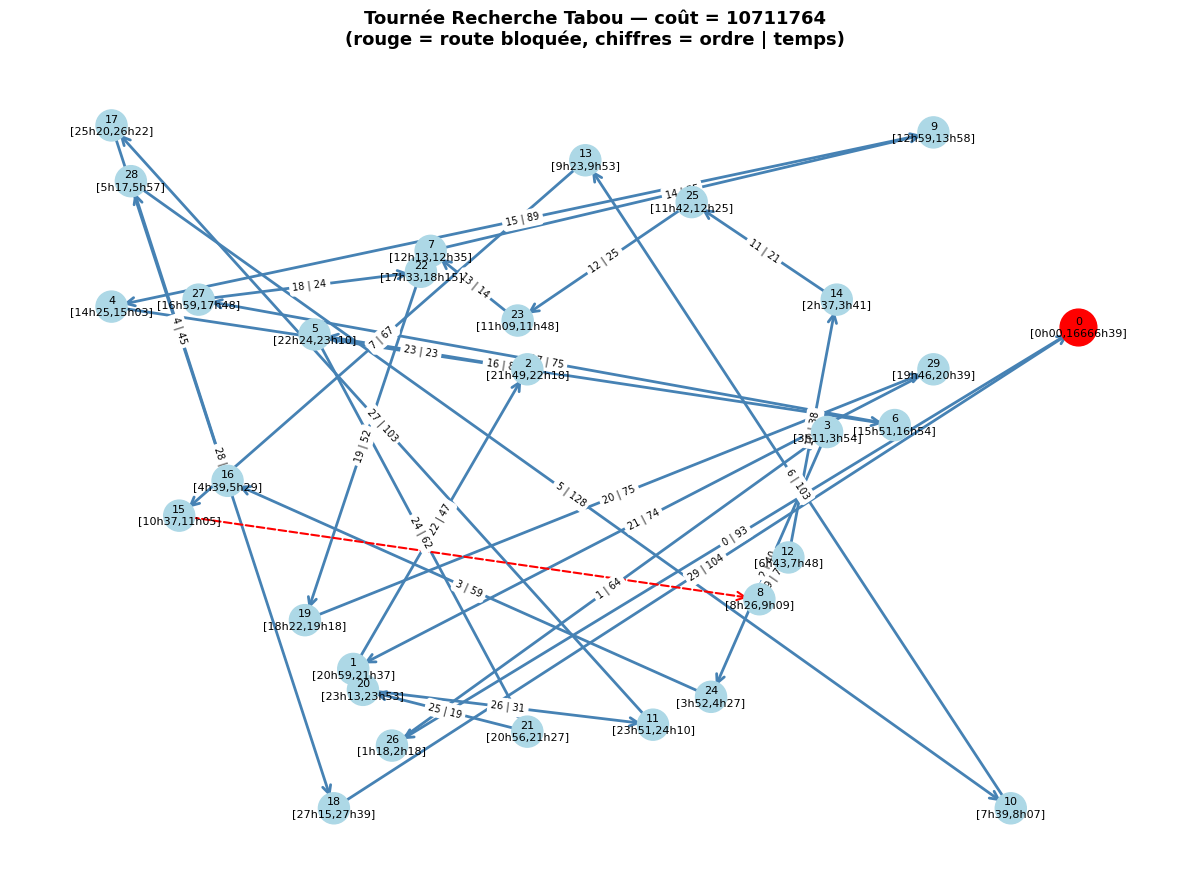

In [24]:
import networkx as nx
from collections import deque

def recherche_tabou_traject(instance, taille_tabou, iter_max):
    nb_villes = len(instance["coordonnees"])

    solution_initiale = list(range(1, nb_villes))
    random.shuffle(solution_initiale)

    nb_iter     = 0
    liste_tabou = deque((), maxlen=taille_tabou)

    solution_courante    = solution_initiale
    meilleure            = solution_initiale
    meilleure_globale    = solution_initiale

    valeur_meilleure         = evaluer_tournee(solution_initiale, instance)
    valeur_meilleure_globale = valeur_meilleure

    courantes            = [valeur_meilleure]
    meilleures_courantes = [valeur_meilleure]

    while nb_iter < iter_max:
        nb_iter += 1
        valeur_meilleure = float("inf")

        for i in range(len(solution_courante)):
            for j in range(i + 1, len(solution_courante)):
                voisin = list(solution_courante)
                voisin[i], voisin[j] = voisin[j], voisin[i]

                if voisin not in liste_tabou:
                    val = evaluer_tournee(voisin, instance)
                    if val < valeur_meilleure:
                        valeur_meilleure = val
                        meilleure        = voisin

        if valeur_meilleure < valeur_meilleure_globale:
            meilleure_globale        = meilleure
            valeur_meilleure_globale = valeur_meilleure
            nb_iter = 0

        meilleures_courantes.append(valeur_meilleure_globale)
        courantes.append(valeur_meilleure)

        solution_courante = meilleure
        liste_tabou.append(meilleure)

    return meilleure_globale, courantes, meilleures_courantes


# --- Lancement ---
iter_max     = TABOU_ITER_MAX
taille_tabou = TABOU_TAILLE

sol, courants, meilleurs_courants = recherche_tabou_traject(data, taille_tabou, iter_max)
tournee_tabou = [0] + sol + [0]

# --- Graphe NetworkX de la tournée ---
G = nx.DiGraph()

coords   = data["coordonnees"]
matrice  = data["matrice_temps"]
fenetres = data["fenetres_temps"]

def min_to_h(m):
    return f"{int(m // 60)}h{int(m % 60):02d}" if isinstance(m, (int, float)) else str(m)

# Ajout des nœuds
for i, (x, y) in coords.items():
    ouv, ferm = fenetres[i]
    label = f"{i}\n[{min_to_h(ouv)},{min_to_h(ferm)}]"
    G.add_node(i, pos=(x, y), label=label)

# Ajout des arcs de la tournée
for k in range(len(tournee_tabou) - 1):
    u = tournee_tabou[k]
    v = tournee_tabou[k + 1]
    G.add_edge(u, v, weight=matrice[u][v], ordre=k)

pos    = nx.get_node_attributes(G, "pos")
labels = nx.get_node_attributes(G, "label")

# Couleurs : dépôt en rouge, villes en bleu
node_colors = ["red" if n == 0 else "lightblue" for n in G.nodes()]
node_sizes  = [700   if n == 0 else 500         for n in G.nodes()]

# Arcs bloqués en rouge pointillé, normaux en bleu
edge_colors = ["red"      if matrice[u][v] >= 999999 else "steelblue" for u, v in G.edges()]
edge_styles = ["dashed"   if matrice[u][v] >= 999999 else "solid"     for u, v in G.edges()]

plt.figure(figsize=(12, 9))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(G, pos, labels, font_size=8)

# Arcs normaux
arcs_normaux = [(u, v) for u, v in G.edges() if matrice[u][v] < 999999]
nx.draw_networkx_edges(G, pos, edgelist=arcs_normaux,
                       arrowstyle="->", arrowsize=15,
                       edge_color="steelblue", width=2)

# Arcs bloqués
arcs_bloques = [(u, v) for u, v in G.edges() if matrice[u][v] >= 999999]
nx.draw_networkx_edges(G, pos, edgelist=arcs_bloques,
                       arrowstyle="->", arrowsize=15,
                       edge_color="red", width=1.5, style="dashed")

# Labels des arcs : ordre | coût
edge_labels = {
    (u, v): f"{d['ordre']} | {d['weight']}"
    for u, v, d in G.edges(data=True)
    if d["weight"] < 999999
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

cout_sol = evaluer_tournee(sol, data)
plt.title(f"Tournée Recherche Tabou — coût = {cout_sol}\n"
          f"(rouge = route bloquée, chiffres = ordre | temps)",
          fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

### Aglorithme 2.1: Tabou Multi Start

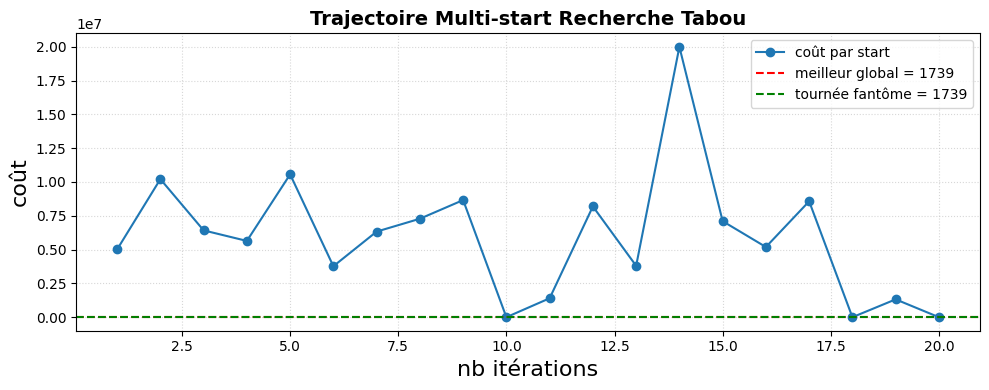

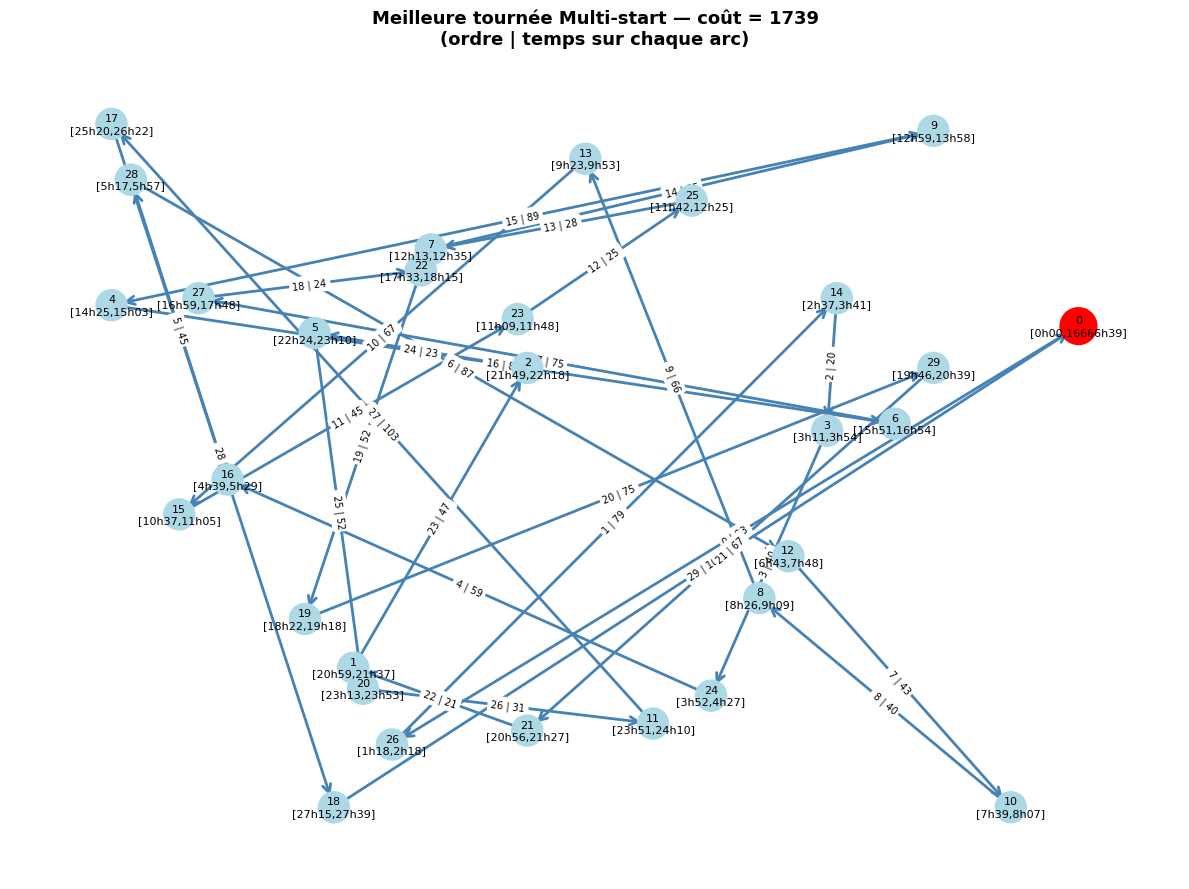

In [25]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque
from ipywidgets import IntProgress
from IPython.display import display

# ============================================================
# MULTI-START RECHERCHE TABOU
# ============================================================

def multi_start_tabou(instance, nb_starts, taille_tabou, iter_max):
    meilleure_solution = None
    meilleur_cout      = float("inf")
    historique_starts  = []

    for _ in range(nb_starts):
        sol, _, _ = recherche_tabou_traject(instance, taille_tabou, iter_max)
        cout = evaluer_tournee(sol, instance)
        historique_starts.append(cout)

        if cout < meilleur_cout:
            meilleur_cout      = cout
            meilleure_solution = sol

    tournee_finale = [0] + meilleure_solution + [0]
    return tournee_finale, meilleur_cout, historique_starts


# ============================================================
# SECTION 1 — Trajectoire du multi-start
# ============================================================

nb_starts    = TABOU_NB_STARTS
taille_tabou = TABOU_TAILLE
iter_max     = TABOU_ITER_MAX

tournee_ms, cout_ms, historique_starts = multi_start_tabou(
    data, nb_starts=nb_starts, taille_tabou=taille_tabou, iter_max=iter_max
)
cout_fantome = evaluer_tournee(data["solution_garantie"][1:-1], data)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(historique_starts)+1), historique_starts,
         marker='o', label="coût par start")
plt.axhline(y=cout_ms,      color='red',   linestyle='--', label=f"meilleur global = {cout_ms}")
plt.axhline(y=cout_fantome, color='green', linestyle='--', label=f"tournée fantôme = {cout_fantome}")
plt.xlabel("nb itérations", fontsize=16)
plt.ylabel("coût", fontsize=16)
plt.title("Trajectoire Multi-start Recherche Tabou", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 2 — Graphe NetworkX de la meilleure tournée multi-start
# ============================================================

def afficher_tournee_networkx(instance, tournee, titre="Tournée"):
    G      = nx.DiGraph()
    coords  = instance["coordonnees"]
    matrice = instance["matrice_temps"]
    fenetres = instance["fenetres_temps"]

    def min_to_h(m):
        return f"{int(m//60)}h{int(m%60):02d}" if isinstance(m, (int, float)) else str(m)

    for i, (x, y) in coords.items():
        ouv, ferm = fenetres[i]
        G.add_node(i, pos=(x, y), label=f"{i}\n[{min_to_h(ouv)},{min_to_h(ferm)}]")

    for k in range(len(tournee) - 1):
        u, v = tournee[k], tournee[k+1]
        G.add_edge(u, v, weight=matrice[u][v], ordre=k)

    pos    = nx.get_node_attributes(G, "pos")
    labels = nx.get_node_attributes(G, "label")

    node_colors = ["red" if n == 0 else "lightblue" for n in G.nodes()]
    node_sizes  = [700   if n == 0 else 500         for n in G.nodes()]

    arcs_normaux = [(u, v) for u, v in G.edges() if matrice[u][v] < 999999]
    arcs_bloques = [(u, v) for u, v in G.edges() if matrice[u][v] >= 999999]

    edge_labels = {
        (u, v): f"{d['ordre']} | {d['weight']}"
        for u, v, d in G.edges(data=True)
        if d["weight"] < 999999
    }

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    nx.draw_networkx_edges(G, pos, edgelist=arcs_normaux,
                           arrowstyle="->", arrowsize=15,
                           edge_color="steelblue", width=2)
    nx.draw_networkx_edges(G, pos, edgelist=arcs_bloques,
                           arrowstyle="->", arrowsize=15,
                           edge_color="red", width=1.5, style="dashed")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    plt.title(titre, fontsize=13, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

afficher_tournee_networkx(data, tournee_ms,
    titre=f"Meilleure tournée Multi-start — coût = {cout_ms}\n(ordre | temps sur chaque arc)")


# ============================================================
# SECTION 3 — Comparaison Tabou simple vs Multi-start sur N instances
# ============================================================

random.seed(42)

nb_tests     = TABOU_NB_TESTS
taille_tabou = TABOU_TAILLE
iter_max     = TABOU_ITER_MAX_COMPARAISON

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

def afficher_graphe(instance, tournee, cout=None, horaires=None):
    G = nx.DiGraph()

    coords = instance["coordonnees"]
    fenetres = horaires if horaires is not None else instance["fenetres_temps"]

    def min_to_h(minutes):
        if isinstance(minutes, (int, float)):
            h = int(minutes // 60)
            m = int(minutes % 60)
            return f"{h}h{m:02d}"
        return str(minutes)

    # Ajouter les noeuds avec positions + infos
    for i, (x, y) in coords.items():
        label = f"{i}"
        if fenetres and i in fenetres:
            ouverture, fermeture = fenetres[i]
            label += f"\n[{min_to_h(ouverture)},{min_to_h(fermeture)}]"

        G.add_node(i, pos=(x, y), label=label)

    # Ajouter les arcs avec poids + ordre
    total_distance = 0
    for i in range(len(tournee) - 1):
        u = tournee[i]
        v = tournee[i + 1]

        x1, y1 = coords[u]
        x2, y2 = coords[v]

        distance = ((x2 - x1)**2 + (y2 - y1)**2) ** 0.5
        total_distance += distance

        G.add_edge(u, v, weight=round(distance, 2), ordre=i)

    pos = nx.get_node_attributes(G, 'pos')
    labels = nx.get_node_attributes(G, 'label')

    plt.figure(figsize=(12, 9))

    # Couleur spéciale pour le dépôt
    node_colors = ["red" if n == 0 else "lightblue" for n in G.nodes()]
    node_sizes  = [700 if n == 0 else 500 for n in G.nodes()]

    # Dessin des noeuds
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors)

    # Dessin des arcs
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color="steelblue", width=2)

    # Labels des noeuds
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

    # Labels des arêtes (ordre | distance)
    edge_labels = {
        (u, v): f"{d['ordre']} | {d['weight']}"
        for u, v, d in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    # Titre enrichi
    titre = "Tournée optimisée (Hill Climbing)\n"
    titre += f"Distance totale = {round(total_distance, 2)}"
    if cout is not None:
        titre += f" | Coût = {round(cout, 2)}"

    plt.title(titre, fontsize=13, fontweight="bold")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### Aglorithme 3 : Reecuit Simulé

In [27]:
def recuit_simule(instance, t_initial=T_INITIAL, t_final=T_FINAL, alpha=ALPHA,
                   iter_par_palier=ITER_PAR_PALIER):
    """
    Algorithme de Recuit Simulé pour le TSP avec contraintes.
    
    Métaheuristique inspirée du recuit métallurgique. Accepte parfois
    des solutions moins bonnes pour échapper aux minima locaux.
    
    Args:
        instance: Dictionnaire de l'instance
        t_initial: Température initiale (haute = plus d'exploration)
        t_final: Température finale (critère d'arrêt)
        alpha: Facteur de refroidissement (0 < alpha < 1)
        iter_par_palier: Itérations par palier de température
    
    Returns:
        tuple: (meilleure_tournee, meilleur_cout, historique)
    """
    nb_villes = len(instance["coordonnees"])
    
    # Solution initiale aléatoire
    tournee_courante = list(range(1, nb_villes))
    random.shuffle(tournee_courante)
    cout_courant = evaluer_tournee(tournee_courante, instance)
    
    # Meilleure solution trouvée
    meilleure_tournee = list(tournee_courante)
    meilleur_cout = cout_courant
    
    historique_couts = [meilleur_cout]
    temp = t_initial
    
    # Boucle de refroidissement
    while temp > t_final:
        for _ in range(iter_par_palier):
            # Générer un voisin (échange de 2 villes)
            voisin = list(tournee_courante)
            idx1, idx2 = random.sample(range(len(voisin)), 2)
            voisin[idx1], voisin[idx2] = voisin[idx2], voisin[idx1]
            
            cout_voisin = evaluer_tournee(voisin, instance)
            delta = cout_voisin - cout_courant
            
            # Critère d'acceptation Metropolis
            if delta < 0 or random.random() < math.exp(-delta / temp):
                tournee_courante = voisin
                cout_courant = cout_voisin
                
                if cout_courant < meilleur_cout:
                    meilleure_tournee = list(tournee_courante)
                    meilleur_cout = cout_courant
                    
        historique_couts.append(meilleur_cout)
        temp *= alpha
        
    tournee_finale = [0] + meilleure_tournee + [0]
    return tournee_finale, meilleur_cout, historique_couts


# Exécution du Recuit Simulé
print("=" * 60)
print("RECUIT SIMULÉ")
print("=" * 60)
meilleure_tournee, cout_opt, historique = recuit_simule(
    data, T_INITIAL, T_FINAL, ALPHA, ITER_PAR_PALIER
)
print(f"Meilleure tournée trouvée : {meilleure_tournee}")
print(f"Coût total (temps + pénalités) : {cout_opt}")

# Comparaison avec la solution garantie
cout_solution_garantie = evaluer_tournee(
    data["solution_garantie"][1:-1], data
)
print(f"Coût de la tournée fantôme (référence) : {cout_solution_garantie}")

RECUIT SIMULÉ
Meilleure tournée trouvée : [0, 26, 14, 3, 24, 16, 28, 12, 10, 8, 13, 15, 23, 9, 25, 7, 4, 27, 19, 1, 2, 6, 29, 22, 5, 20, 21, 11, 17, 18, 0]
Coût total (temps + pénalités) : 12491771
Coût de la tournée fantôme (référence) : 1739


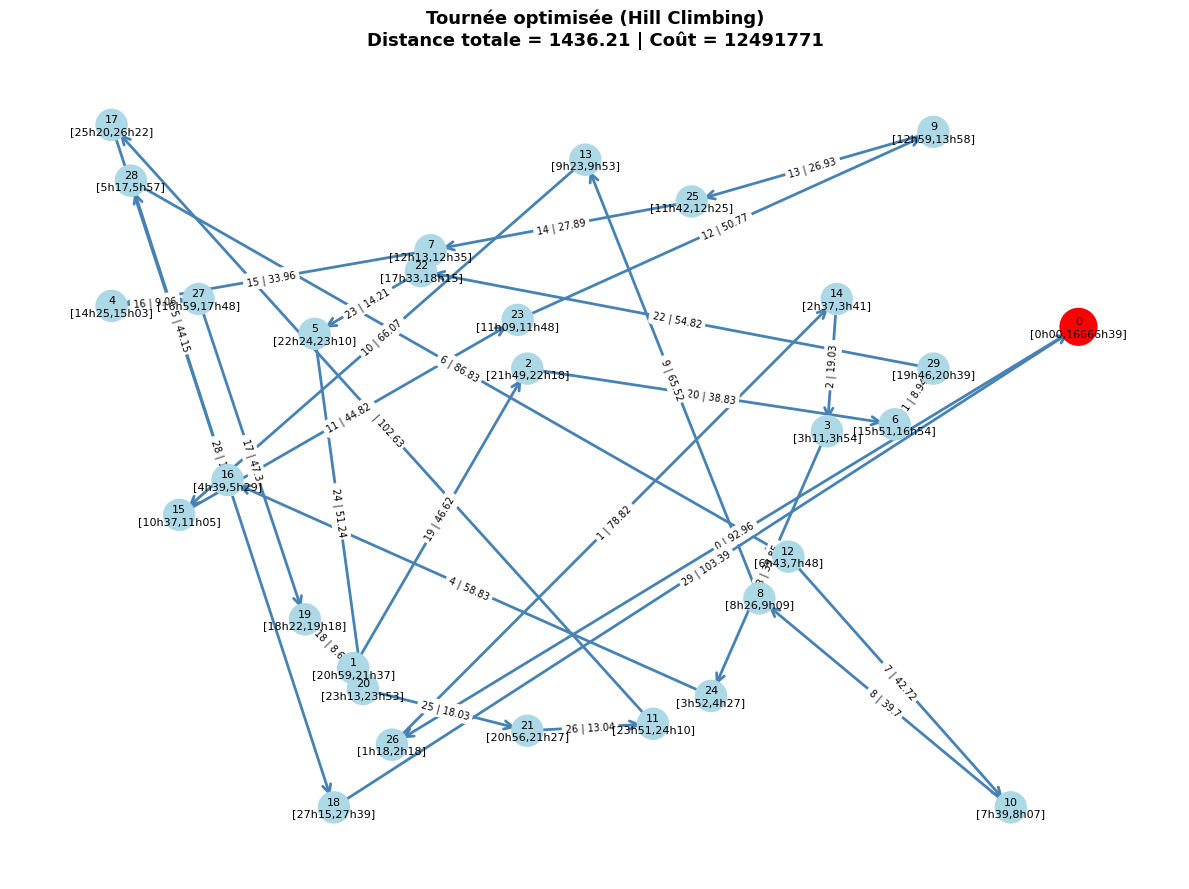

In [28]:
# Affichage du graphe pour le Recuit Simulé
afficher_graphe(data, meilleure_tournee, cout=cout_opt)

### Aglorithme exact : Pulp (Branch and Cut)

In [29]:
# Installation de PuLP si nécessaire (décommenter la ligne ci-dessous si besoin)
# !pip install pulp

try:
    import pulp
except ImportError:
    print("PuLP n'est pas installé. Exécutez: pip install pulp")
    pulp = None

def resoudre_exactement_pulp(instance, timeout=30):
    """
    Résolution exacte du TSP avec fenêtres temporelles et restrictions d'arêtes.
    
    CONTRAINTES PRISES EN COMPTE :
    - Fenêtres temporelles (Time Windows)
    - Routes bloquées (exclues du modèle)
    - Surcoûts sur certaines arêtes
    
    ATTENTION: Très lent pour n > 12-15 villes (complexité exponentielle).
    
    Args:
        instance: Dictionnaire avec coordonnees, matrice_temps, 
                  matrice_restrictions, fenetres_temps
        timeout: Temps maximum en secondes (défaut: 30s)
    
    Returns:
        (tournee, cout, statut)
    """
    if pulp is None:
        return None, None, "PuLP non installé"
    
    nb_villes = len(instance["coordonnees"])
    matrice = instance["matrice_temps"]
    restrictions = instance.get("matrice_restrictions", None)
    fenetres = instance["fenetres_temps"]

    # Identifier les arêtes valides (non bloquées)
    aretes_valides = []
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j:
                # Arête valide si pas de restriction OU restriction > 0
                if restrictions is None or restrictions[i][j] > 0:
                    aretes_valides.append((i, j))
    
    prob = pulp.LpProblem("TSP_TimeWindows", pulp.LpMinimize)

    # Variables de décision - UNIQUEMENT pour les arêtes valides
    x = pulp.LpVariable.dicts("x", aretes_valides, cat='Binary')
    t = pulp.LpVariable.dicts("t", range(nb_villes), lowBound=0, 
                              cat='Continuous')
    t_fin = pulp.LpVariable("t_fin", lowBound=0, cat='Continuous')

    # Fonction objectif : minimiser le temps total
    prob += t_fin

    # Contraintes de flux - adaptées aux arêtes valides
    # Sortie du dépôt
    prob += pulp.lpSum([x[0, j] for j in range(1, nb_villes) 
                        if (0, j) in aretes_valides]) == 1
    # Retour au dépôt
    prob += pulp.lpSum([x[i, 0] for i in range(1, nb_villes) 
                        if (i, 0) in aretes_valides]) == 1
    
    # Chaque ville visitée exactement une fois
    for k in range(1, nb_villes):
        prob += pulp.lpSum([x[i, k] for i in range(nb_villes) 
                            if i != k and (i, k) in aretes_valides]) == 1
        prob += pulp.lpSum([x[k, j] for j in range(nb_villes) 
                            if j != k and (k, j) in aretes_valides]) == 1

    M = 100000
    
    # CONTRAINTE 1 : Fenêtres temporelles
    prob += t[0] == 0
    for i in range(1, nb_villes):
        ouv, ferm = fenetres[i]
        prob += t[i] >= ouv
        prob += t[i] <= ferm

    # Contraintes MTZ - uniquement pour arêtes valides
    for (i, j) in aretes_valides:
        if j != 0:  # Pas pour le retour au dépôt
            prob += t[j] >= t[i] + matrice[i][j] - M * (1 - x[i, j])
    
    # Contrainte sur t_fin
    for i in range(1, nb_villes):
        if (i, 0) in aretes_valides:
            prob += t_fin >= t[i] + matrice[i][0] - M * (1 - x[i, 0])

    # Résolution avec timeout
    status = prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=timeout))
    
    if pulp.LpStatus[status] == "Optimal":
        # Reconstruction de la tournée
        ville_actuelle = 0
        tournee = [0]
        visited = {0}
        while len(tournee) < nb_villes + 1:
            found = False
            for j in range(nb_villes):
                if j not in visited and (ville_actuelle, j) in aretes_valides:
                    val = pulp.value(x[ville_actuelle, j])
                    if val is not None and val > 0.5:
                        tournee.append(j)
                        visited.add(j)
                        ville_actuelle = j
                        found = True
                        break
            if not found:
                if len(tournee) == nb_villes:
                    tournee.append(0)
                break
        
        cout = pulp.value(t_fin)
        return tournee, cout, pulp.LpStatus[status]
    
    return None, None, pulp.LpStatus[status]

# Exécution de la résolution exacte
print("=" * 60)
print("RÉSOLUTION EXACTE (PuLP - Programmation Linéaire)")
print(f"⚠️  Attention: peut être lent pour n > 12 villes")
print("=" * 60)

if NB_VILLES <= PULP_SEUIL_VILLES:
    tournee_pulp, cout_pulp, statut_pulp = resoudre_exactement_pulp(
        data, timeout=PULP_TIMEOUT
    )
    print(f"Statut du solveur : {statut_pulp}")
    if tournee_pulp:
        print(f"Tournée optimale : {tournee_pulp}")
        print(f"Coût optimal : {cout_pulp}")
    else:
        print("Pas de solution trouvée par PuLP.")
else:
    print(f"⏭️  PuLP ignoré (n={NB_VILLES} > {PULP_SEUIL_VILLES}, trop lent)")
    print("   Utilisez les heuristiques pour les grandes instances.")
    tournee_pulp, cout_pulp, statut_pulp = None, None, "Skipped"

RÉSOLUTION EXACTE (PuLP - Programmation Linéaire)
⚠️  Attention: peut être lent pour n > 12 villes
⏭️  PuLP ignoré (n=30 > 12, trop lent)
   Utilisez les heuristiques pour les grandes instances.


#### Affichage Pulp

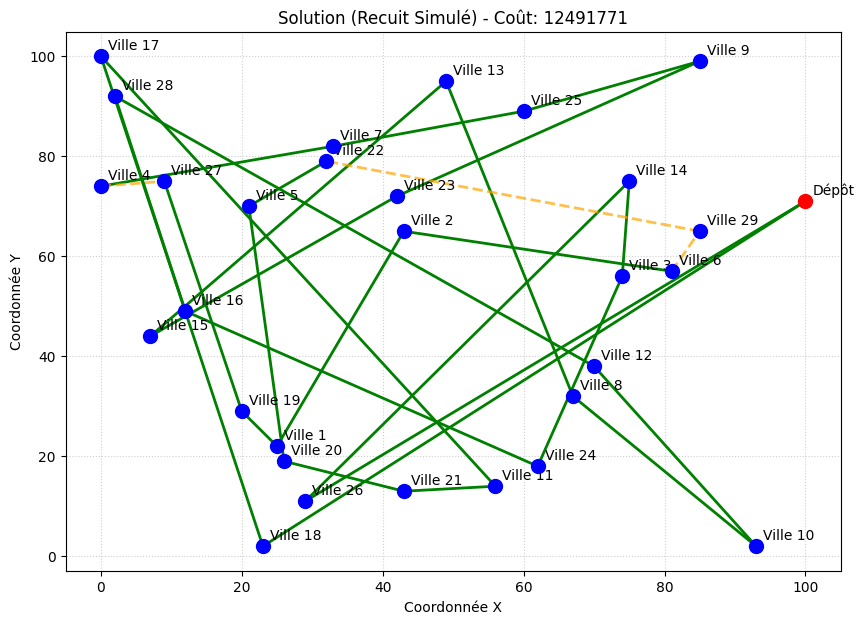

In [30]:
import matplotlib.pyplot as plt

def afficher_tournee(tournee, instance, titre="Tournée de livraison"):
    """
    Affiche graphiquement une tournée sur le plan des coordonnées.
    
    Args:
        tournee: Liste des villes dans l'ordre de visite (avec dépôt au début et fin)
        instance: Dictionnaire contenant coordonnees et matrice_temps
        titre: Titre du graphique
    """
    coords = instance["coordonnees"]
    matrice = instance["matrice_temps"]
    
    plt.figure(figsize=(10, 7))
    
    # 1. Dessiner les villes
    for i, (x, y) in coords.items():
        color = 'red' if i == 0 else 'blue'
        label = f"Dépôt" if i == 0 else f"Ville {i}"
        plt.scatter(x, y, c=color, s=100, zorder=5)
        plt.annotate(label, (x, y), xytext=(5, 5), textcoords='offset points')

    # 2. Dessiner les trajets
    for k in range(len(tournee) - 1):
        p1 = coords[tournee[k]]
        p2 = coords[tournee[k+1]]
        
        # Arêtes avec surcoût en pointillé orange, normales en vert
        temps_base = math.hypot(p2[0]-p1[0], p2[1]-p1[1])
        temps_reel = matrice[tournee[k]][tournee[k+1]]
        
        if temps_reel > temps_base * 1.4:  # Surcoût détecté
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'orange', linestyle='--', linewidth=2, alpha=0.7)
        else:
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2)

    plt.title(titre)
    plt.xlabel("Coordonnée X")
    plt.ylabel("Coordonnée Y")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Affichage des résultats
if tournee_pulp:
    afficher_tournee(tournee_pulp, data, titre=f"Solution Optimale (PuLP) - Coût: {cout_pulp}")
else:
    # On affiche la solution du recuit simulé si PuLP n'a pas trouvé de solution
    afficher_tournee(meilleure_tournee, data, titre=f"Solution (Recuit Simulé) - Coût: {cout_opt}")

## 8. Plan d'expérience <a id="8"></a>

In [31]:
import time

def benchmark_algorithmes(instance, nb_runs=5):
    """
    Compare les performances des 3 algorithmes sur une même instance.
    
    Returns:
        Dictionnaire avec les résultats de chaque algorithme
    """
    resultats = {
        "Hill Climbing": {"couts": [], "temps": [], "tournees": []},
        "Recuit Simulé": {"couts": [], "temps": [], "tournees": []},
        "PuLP (Exact)": {"couts": [], "temps": [], "tournees": []}
    }
    
    print(f"🔄 Benchmark en cours ({nb_runs} runs par algorithme)...\n")
    
    # Hill Climbing
    for i in range(nb_runs):
        start = time.time()
        tournee, cout, _ = hill_climbing(instance, max_iter=HC_MAX_ITER)
        elapsed = time.time() - start
        resultats["Hill Climbing"]["couts"].append(cout)
        resultats["Hill Climbing"]["temps"].append(elapsed)
        resultats["Hill Climbing"]["tournees"].append(tournee)
    
    # Recuit Simulé
    for i in range(nb_runs):
        start = time.time()
        tournee, cout, _ = recuit_simule(instance, T_INITIAL, T_FINAL, ALPHA, ITER_PAR_PALIER)
        elapsed = time.time() - start
        resultats["Recuit Simulé"]["couts"].append(cout)
        resultats["Recuit Simulé"]["temps"].append(elapsed)
        resultats["Recuit Simulé"]["tournees"].append(tournee)
    
    # PuLP (1 seul run car déterministe)
    if NB_VILLES <= 12:
        start = time.time()
        tournee, cout, statut = resoudre_exactement_pulp(instance, timeout=PULP_TIMEOUT)
        elapsed = time.time() - start
        if tournee and cout:
            resultats["PuLP (Exact)"]["couts"].append(cout)
            resultats["PuLP (Exact)"]["temps"].append(elapsed)
            resultats["PuLP (Exact)"]["tournees"].append(tournee)
    
    return resultats

# Lancer le benchmark
resultats = benchmark_algorithmes(data, nb_runs=BENCHMARK_NB_RUNS)

# Calcul des statistiques
print("=" * 70)
print("📊 TABLEAU COMPARATIF DES ALGORITHMES")
print("=" * 70)
print(f"{'Algorithme':<20} {'Coût min':<12} {'Coût moyen':<12} {'Coût max':<12} {'Temps moyen':<12}")
print("-" * 70)

for algo, stats in resultats.items():
    if stats["couts"]:
        cout_min = min(stats["couts"])
        cout_moy = sum(stats["couts"]) / len(stats["couts"])
        cout_max = max(stats["couts"])
        temps_moy = sum(stats["temps"]) / len(stats["temps"])
        print(f"{algo:<20} {cout_min:<12.0f} {cout_moy:<12.1f} {cout_max:<12.0f} {temps_moy:<12.4f}s")
    else:
        print(f"{algo:<20} {'N/A':<12} {'N/A':<12} {'N/A':<12} {'N/A':<12}")

# Référence : solution garantie
cout_ref = evaluer_tournee(data["solution_garantie"][1:-1], data)
print("-" * 70)
print(f"{'Référence (fantôme)':<20} {cout_ref:<12.0f}")
print("=" * 70)

🔄 Benchmark en cours (5 runs par algorithme)...

📊 TABLEAU COMPARATIF DES ALGORITHMES
Algorithme           Coût min     Coût moyen   Coût max     Temps moyen 
----------------------------------------------------------------------
Hill Climbing        2661764      5307758.6    9321762      0.3557      s
Recuit Simulé        8271767      16411770.4   25951788     1.0149      s
PuLP (Exact)         N/A          N/A          N/A          N/A         
----------------------------------------------------------------------
Référence (fantôme)  1739        


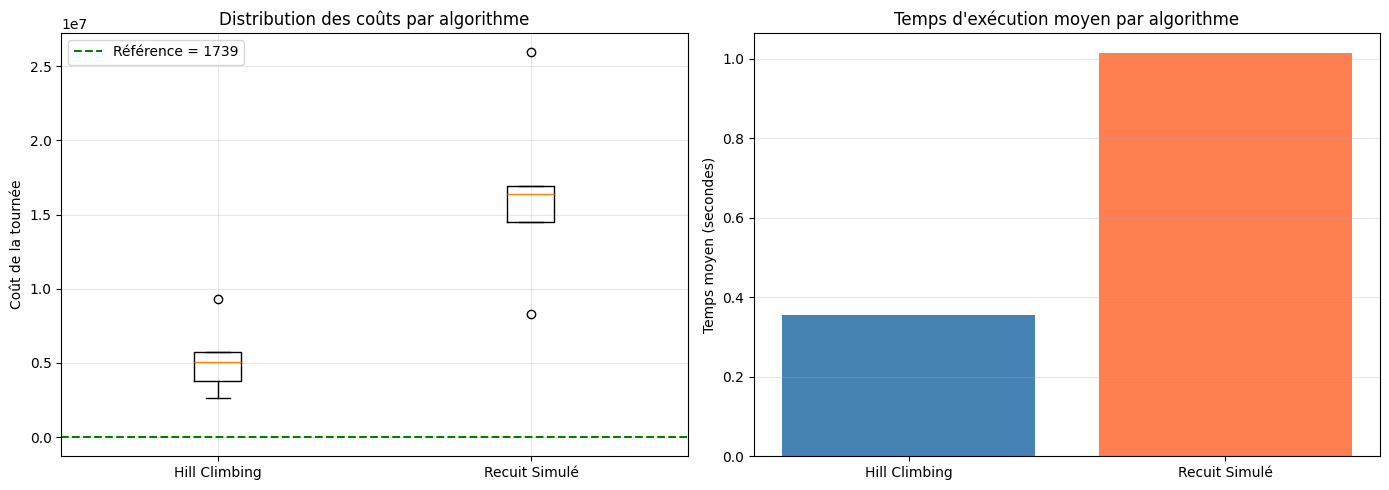

In [32]:
import matplotlib.pyplot as plt

# Graphique 1 : Comparaison des coûts par algorithme (boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot des coûts
algos_avec_donnees = [algo for algo, stats in resultats.items() if stats["couts"]]
couts_par_algo = [resultats[algo]["couts"] for algo in algos_avec_donnees]

if couts_par_algo:
    axes[0].boxplot(couts_par_algo, tick_labels=algos_avec_donnees)
    axes[0].set_ylabel("Coût de la tournée")
    axes[0].set_title("Distribution des coûts par algorithme")
    axes[0].axhline(y=cout_ref, color='green', linestyle='--', 
                    label=f'Référence = {cout_ref}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Barplot des temps d'exécution moyens
temps_moyens = [
    sum(resultats[algo]["temps"]) / len(resultats[algo]["temps"]) 
    if resultats[algo]["temps"] else 0 
    for algo in algos_avec_donnees
]
colors = ['steelblue', 'coral', 'seagreen'][:len(algos_avec_donnees)]
axes[1].bar(algos_avec_donnees, temps_moyens, color=colors)
axes[1].set_ylabel("Temps moyen (secondes)")
axes[1].set_title("Temps d'exécution moyen par algorithme")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

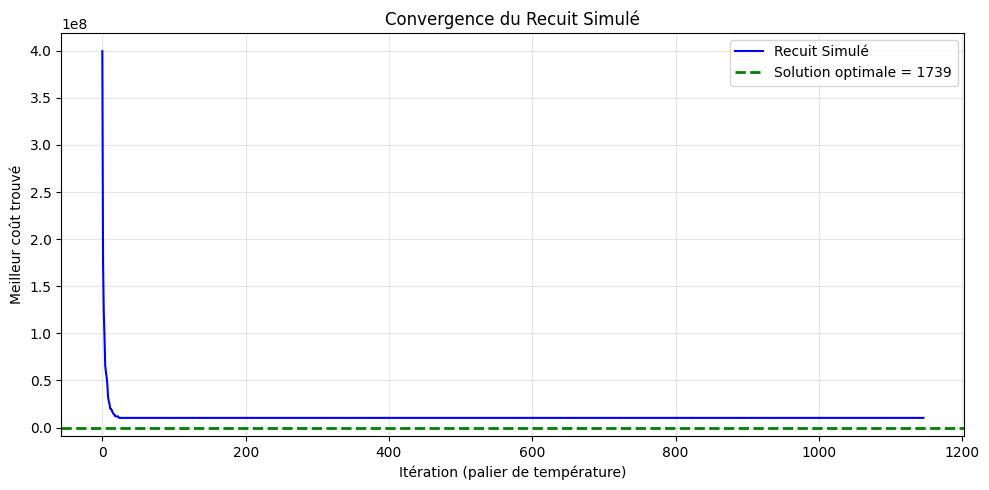

In [33]:
# Graphique 2 : Convergence du Recuit Simulé
# On relance une fois pour capturer l'historique complet
_, _, historique_rs = recuit_simule(data, T_INITIAL, T_FINAL, ALPHA, ITER_PAR_PALIER)

plt.figure(figsize=(10, 5))
plt.plot(historique_rs, 'b-', linewidth=1.5, label='Recuit Simulé')
plt.axhline(y=cout_ref, color='green', linestyle='--', linewidth=2, label=f'Solution optimale = {cout_ref}')
plt.xlabel("Itération (palier de température)")
plt.ylabel("Meilleur coût trouvé")
plt.title("Convergence du Recuit Simulé")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

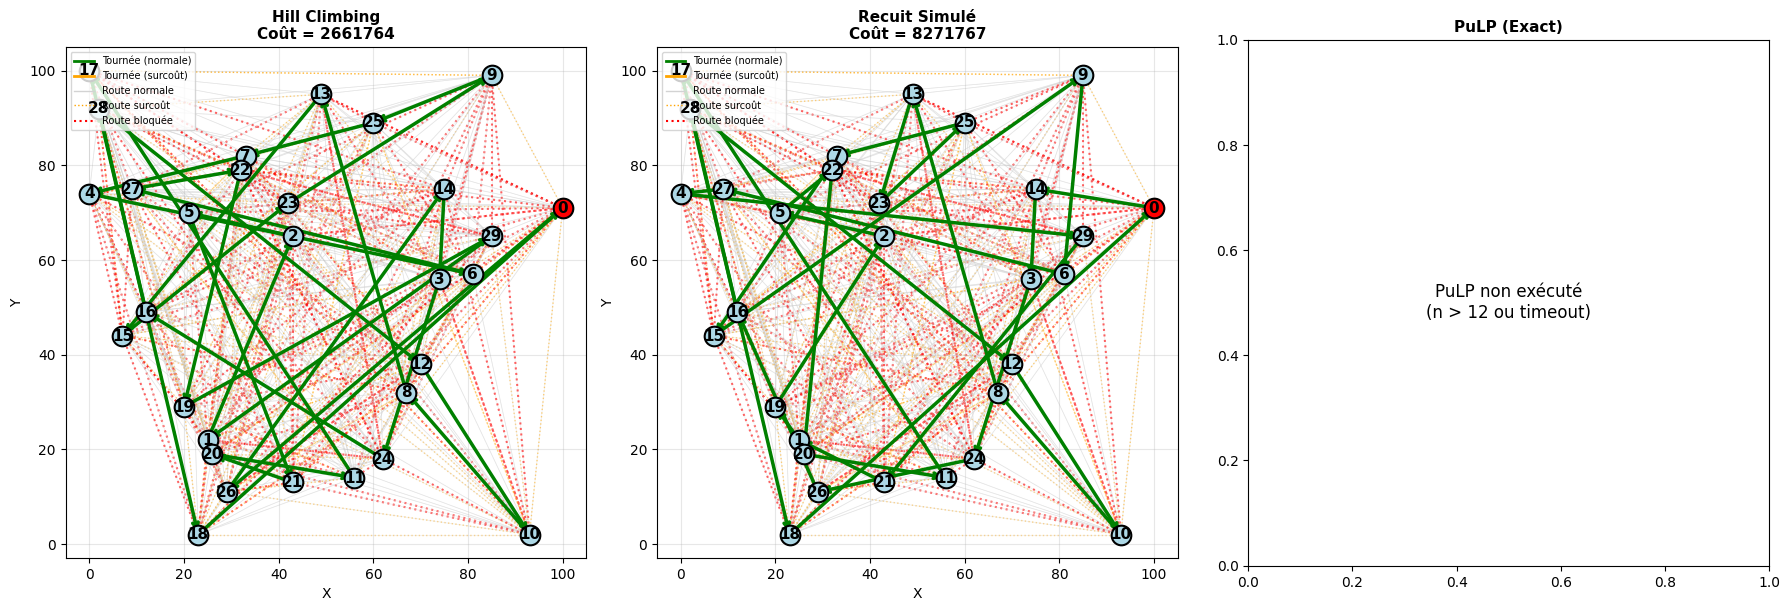


📌 Légende des arêtes :
   🟢 Vert épais    : Route normale utilisée dans la tournée
   🟠 Orange épais  : Route avec surcoût utilisée dans la tournée
   ⚪ Gris fin      : Route normale non utilisée
   🟠 Orange pointillé : Route avec surcoût non utilisée
   🔴 Rouge pointillé  : Route BLOQUÉE (interdite)


In [34]:
# Affichage côte à côte des meilleures tournées avec TOUTES les arêtes du graphe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def dessiner_tournee_complete(ax, tournee, instance, titre, couleur_tournee='green'):
    """
    Affiche une tournée avec :
    - Routes bloquées (rouge pointillé)
    - Routes avec surcoût (orange pointillé)
    - Routes normales non utilisées (gris)
    - Tournée sélectionnée (vert/orange épais)
    """
    coords = instance["coordonnees"]
    matrice = instance["matrice_temps"]
    restrictions = instance.get("matrice_restrictions", None)
    nb_villes = len(coords)
    
    # Calculer les distances de base pour détecter les surcoûts
    distances_base = {}
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j:
                xi, yi = coords[i]
                xj, yj = coords[j]
                distances_base[(i,j)] = math.ceil(math.hypot(xj - xi, yj - yi))
    
    # Arêtes de la tournée
    aretes_tournee = set()
    for k in range(len(tournee) - 1):
        aretes_tournee.add((tournee[k], tournee[k+1]))
    
    # 1. Dessiner TOUTES les arêtes du graphe (en arrière-plan)
    for i in range(nb_villes):
        for j in range(nb_villes):
            if i != j and (i, j) not in aretes_tournee:
                p1 = coords[i]
                p2 = coords[j]
                
                # Vérifier le type de restriction
                if restrictions is not None:
                    restriction = restrictions[i][j]
                    if restriction == 0:  # Route bloquée
                        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                               color='red', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
                    elif restriction > 1:  # Surcoût
                        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                               color='orange', linestyle=':', linewidth=1, alpha=0.5, zorder=1)
                    else:  # Normal
                        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                               color='lightgray', linestyle='-', linewidth=0.5, alpha=0.4, zorder=1)
                else:
                    # Ancienne méthode (sans matrice_restrictions)
                    temps_base = distances_base[(i,j)]
                    temps_reel = matrice[i][j]
                    if temps_reel >= 999999:
                        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                               color='red', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
                    elif temps_reel > temps_base * 1.4:
                        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                               color='orange', linestyle=':', linewidth=1, alpha=0.5, zorder=1)
                    else:
                        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 
                               color='lightgray', linestyle='-', linewidth=0.5, alpha=0.4, zorder=1)
    
    # 2. Dessiner la tournée sélectionnée (en avant-plan)
    for k in range(len(tournee) - 1):
        p1 = coords[tournee[k]]
        p2 = coords[tournee[k+1]]
        i, j = tournee[k], tournee[k+1]
        
        # Déterminer la couleur selon le type d'arête
        if restrictions is not None:
            restriction = restrictions[i][j]
            if restriction == 0:
                couleur = 'red'  # Route bloquée (ne devrait pas arriver)
            elif restriction > 1:
                couleur = 'orange'  # Surcoût
            else:
                couleur = couleur_tournee  # Normal
        else:
            temps_base = distances_base[(i,j)]
            temps_reel = matrice[i][j]
            if temps_reel >= 999999:
                couleur = 'red'
            elif temps_reel > temps_base * 1.4:
                couleur = 'orange'
            else:
                couleur = couleur_tournee
        
        ax.annotate('', xy=p2, xytext=p1,
                   arrowprops=dict(arrowstyle='->', color=couleur, lw=2.5), zorder=3)
    
    # 3. Dessiner les villes
    for i, (x, y) in coords.items():
        color = 'red' if i == 0 else 'lightblue'
        ax.scatter(x, y, c=color, s=200, zorder=5, edgecolors='black', linewidths=1.5)
        ax.annotate(str(i), (x, y), ha='center', va='center', fontsize=11, fontweight='bold', zorder=6)
    
    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Légende
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='green', lw=2, label='Tournée (normale)'),
        Line2D([0], [0], color='orange', lw=2, label='Tournée (surcoût)'),
        Line2D([0], [0], color='lightgray', lw=1, label='Route normale'),
        Line2D([0], [0], color='orange', lw=1, linestyle=':', label='Route surcoût'),
        Line2D([0], [0], color='red', lw=1.5, linestyle=':', label='Route bloquée')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=7)

# Meilleure tournée de chaque algorithme
if resultats["Hill Climbing"]["tournees"]:
    idx_best_hc = resultats["Hill Climbing"]["couts"].index(min(resultats["Hill Climbing"]["couts"]))
    best_hc = resultats["Hill Climbing"]["tournees"][idx_best_hc]
    dessiner_tournee_complete(axes[0], best_hc, data, 
                              f"Hill Climbing\nCoût = {min(resultats['Hill Climbing']['couts'])}")

if resultats["Recuit Simulé"]["tournees"]:
    idx_best_rs = resultats["Recuit Simulé"]["couts"].index(min(resultats["Recuit Simulé"]["couts"]))
    best_rs = resultats["Recuit Simulé"]["tournees"][idx_best_rs]
    dessiner_tournee_complete(axes[1], best_rs, data,
                              f"Recuit Simulé\nCoût = {min(resultats['Recuit Simulé']['couts'])}")

if resultats["PuLP (Exact)"]["tournees"]:
    best_pulp = resultats["PuLP (Exact)"]["tournees"][0]
    dessiner_tournee_complete(axes[2], best_pulp, data,
                              f"PuLP (Exact)\nCoût = {resultats['PuLP (Exact)']['couts'][0]}")
else:
    axes[2].text(0.5, 0.5, "PuLP non exécuté\n(n > 12 ou timeout)", 
                ha='center', va='center', fontsize=12, transform=axes[2].transAxes)
    axes[2].set_title("PuLP (Exact)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📌 Légende des arêtes :")
print("   🟢 Vert épais    : Route normale utilisée dans la tournée")
print("   🟠 Orange épais  : Route avec surcoût utilisée dans la tournée")
print("   ⚪ Gris fin      : Route normale non utilisée")
print("   🟠 Orange pointillé : Route avec surcoût non utilisée")
print("   🔴 Rouge pointillé  : Route BLOQUÉE (interdite)")

---
## 9. Limitations et Perspectives <a id="9"></a>

### 9.1 Analyse des résultats expérimentaux

Les expérimentations menées sur notre instance de test révèlent des comportements distincts pour chaque algorithme :

| Algorithme | Avantages | Inconvénients |
|------------|-----------|---------------|
| **Hill Climbing** | Rapide, simple à implémenter, convergence garantie | Peut rester bloqué dans un minimum local |
| **Recuit Simulé** | Explore mieux l'espace des solutions, évite les minima locaux | Plus lent, paramètres (T, α) à régler finement |
| **PuLP (PLNE)** | Garantit l'optimum global si solution existe | Très lent pour n > 12-15 villes (complexité exponentielle) |

### 9.2 Limitations identifiées

#### Limitations algorithmiques
1. **Scalabilité de la méthode exacte** : La résolution par programmation linéaire (PuLP) devient impraticable au-delà de 15 villes en raison de la complexité exponentielle du TSP.

2. **Sensibilité aux conditions initiales** : Les heuristiques (Hill Climbing, Recuit Simulé) dépendent fortement de la solution initiale aléatoire, ce qui peut conduire à des résultats très variables.

3. **Fenêtres temporelles strictes** : L'utilisation de *hard time windows* réduit considérablement l'espace des solutions faisables et peut rendre certaines instances insolubles.

#### Limitations du modèle
4. **Graphe statique** : Notre modèle ne prend pas en compte les variations temporelles du trafic (heures de pointe, conditions météo).

5. **Véhicule unique** : Le modèle actuel ne gère qu'un seul véhicule. L'extension au VRP (Vehicle Routing Problem) multi-véhicules nécessiterait des adaptations significatives.

6. **Capacité non modélisée** : Bien que mentionnée dans le contexte, la contrainte de capacité du véhicule n'est pas implémentée dans cette version.

### 9.3 Perspectives d'amélioration

#### Améliorations algorithmiques
- **Algorithme génétique** : Combiner les meilleures solutions (crossover) pour explorer plus efficacement l'espace des solutions.
- **Recherche tabou** : Éviter de revisiter les solutions récemment explorées pour sortir des minima locaux.
- **Hybridation** : Utiliser une heuristique rapide pour initialiser PuLP sur de petites sous-instances.
- **Parallélisation** : Exécuter plusieurs runs simultanément (multi-start) pour améliorer la robustesse.

#### Extensions du modèle
- **Soft Time Windows** : Autoriser les retards avec pénalité plutôt que de les interdire strictement.
- **Multi-véhicules** : Étendre au problème VRP avec flotte hétérogène.
- **Dynamisme** : Intégrer des mises à jour en temps réel (nouveaux clients, routes bloquées).
- **Multi-objectif** : Optimiser simultanément le temps, le coût et l'empreinte carbone.

### 9.4 Conclusion

Ce livrable pose les fondations théoriques et pratiques pour la résolution du TSPTW-R. Les trois approches implémentées (Hill Climbing, Recuit Simulé, PLNE) offrent un compromis différent entre qualité de solution et temps de calcul. Pour les applications industrielles avec des centaines de points de livraison, les métaheuristiques restent l'approche privilégiée, potentiellement hybridées avec des techniques exactes sur des sous-problèmes.